# 02 Baseline U-Net

This notebook implements the baseline U-Net model using the processed STRUM RGB dataset.

Input:
- RGB Sentinel-2 images
- Shape: (3,128,128)

Output:
- Binary flood segmentation mask
- Shape: (1,128,128)

The baseline model will be used for comparison against the Hybrid SAM-U-Net architecture.

In [2]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [3]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

D:\Users\Anusuya\anaconda3\python.exe
2.11.0+cu128
12.8
True


In [4]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

IMAGE_SIZE = 128

BATCH_SIZE = 8

LEARNING_RATE = 5e-5

EPOCHS = 100

Device: cuda


In [6]:
PROCESSED_PATH = Path(r"D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\dataset\processed\STRUM")

TRAIN_IMAGE_DIR = (PROCESSED_PATH /"train" /"images")

TRAIN_MASK_DIR = ( PROCESSED_PATH / "train" /"masks")

VAL_IMAGE_DIR = (PROCESSED_PATH /"val" /"images")

VAL_MASK_DIR = ( PROCESSED_PATH /"val" /"masks")

TEST_IMAGE_DIR = ( PROCESSED_PATH /"test" / "images")

TEST_MASK_DIR = ( PROCESSED_PATH / "test" / "masks")

In [7]:
train_images = sorted(
    list(TRAIN_IMAGE_DIR.glob("*.npy"))
)

train_masks = sorted(
    list(TRAIN_MASK_DIR.glob("*.npy"))
)

print("Train Images:", len(train_images))
print("Train Masks :", len(train_masks))

Train Images: 2140
Train Masks : 2140


In [8]:
sample_image = np.load(
    train_images[0]
)

sample_mask = np.load(
    train_masks[0]
)

print("Image Shape :", sample_image.shape)
print("Mask Shape  :", sample_mask.shape)

print("Image Min   :", sample_image.min())
print("Image Max   :", sample_image.max())

print("Mask Classes:", np.unique(sample_mask))

Image Shape : (3, 128, 128)
Mask Shape  : (128, 128)
Image Min   : 0.0
Image Max   : 1.0
Mask Classes: [0 1]


In [9]:
print(
    "Image Has NaN:",
    np.isnan(sample_image).any()
)

print(
    "Image Has Inf:",
    np.isinf(sample_image).any()
)

print(
    "Mask Has NaN:",
    np.isnan(sample_mask).any()
)

Image Has NaN: False
Image Has Inf: False
Mask Has NaN: False


In [10]:
bad_images = 0

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_images += 1

print(
    "Images Containing NaN:",
    bad_images
)

Images Containing NaN: 0


In [11]:
sample_image.shape
sample_mask.shape

sample_image.min()
sample_image.max()

np.unique(sample_mask)

array([0, 1], dtype=uint8)

In [20]:
bad_files = []

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_files.append(file)

print("Bad Files Found:", len(bad_files))

for f in bad_files:
    print(f)

Bad Files Found: 0


In [ ]:
x = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    y = model(x)

print(y.shape)

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {total_params:,}"
)

## Dataset Class

Loads processed RGB images and binary masks from the processed STRUM dataset.

In [24]:
import random
from pathlib import Path
from torch.utils.data import Dataset
import numpy as np
import torch


class FloodDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        augment=False
    ):

        self.images = sorted(
            list(Path(image_dir).glob("*.npy"))
        )

        self.masks = sorted(
            list(Path(mask_dir).glob("*.npy"))
        )

        self.augment = augment

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # Load image
        image = np.load(
            self.images[idx]
        )

        # Load mask
        mask = np.load(
            self.masks[idx]
        )

        # =====================
        # Data Augmentation
        # =====================

        if self.augment:

            # Horizontal Flip
            if random.random() > 0.5:

                image = np.flip(
                    image,
                    axis=2
                ).copy()

                mask = np.flip(
                    mask,
                    axis=1
                ).copy()

            # Vertical Flip
            if random.random() > 0.5:

                image = np.flip(
                    image,
                    axis=1
                ).copy()

                mask = np.flip(
                    mask,
                    axis=0
                ).copy()

            # Random 90° Rotation
            k = random.randint(0, 3)

            image = np.rot90(
                image,
                k,
                axes=(1, 2)
            ).copy()

            mask = np.rot90(
                mask,
                k
            ).copy()

        # Add channel dimension
        mask = np.expand_dims(
            mask,
            axis=0
        )

        # Convert to tensor
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        return image, mask

In [26]:
train_dataset = FloodDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    augment=True
)

val_dataset = FloodDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    augment=False
)

test_dataset = FloodDataset(
    TEST_IMAGE_DIR,
    TEST_MASK_DIR,
    augment=False
)

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [30]:
mask_files = list(
    Path(TRAIN_MASK_DIR).glob("*.npy")
)

water_pixels = 0
background_pixels = 0

for mask_file in mask_files:

    mask = np.load(mask_file)

    water_pixels += np.sum(mask == 1)
    background_pixels += np.sum(mask == 0)

pos_weight = background_pixels / water_pixels

print("Background:", background_pixels)
print("Water:", water_pixels)
print("Pos Weight:", pos_weight)

Background: 25243294
Water: 9818466
Pos Weight: 2.5710018245212645


In [31]:
image, mask = train_dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape :", mask.shape)

print("Image Min :", image.min())
print("Image Max :", image.max())

print("Mask Classes:")
print(torch.unique(mask))

Image Shape: torch.Size([3, 128, 128])
Mask Shape : torch.Size([1, 128, 128])
Image Min : tensor(0.)
Image Max : tensor(1.)
Mask Classes:
tensor([0., 1.])


In [32]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

print(torch.unique(masks))

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])
tensor([0., 1.])


## U-Net Architecture

Baseline U-Net for binary flood segmentation.

Input:
- RGB Image (3×128×128)

Output:
- Binary Flood Mask (1×128×128)

In [34]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [39]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):

        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Encoder

        self.down1 = DoubleConv(
            in_channels,
            64
        )

        self.down2 = DoubleConv(
            64,
            128
        )

        self.down3 = DoubleConv(
            128,
            256
        )

        self.down4 = DoubleConv(
            256,
            512
        )

        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        self.dropout = nn.Dropout2d(0.5) #extra

        # Decoder

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        d1 = self.down1(x)

        d2 = self.down2(
            self.pool(d1)
        )

        d3 = self.down3(
            self.pool(d2)
        )

        d4 = self.down4(
            self.pool(d3)
        )

        bottleneck = self.bottleneck(
            self.pool(d4)
        )

        bottleneck = self.dropout(bottleneck) #extra

        u4 = self.up4(
            bottleneck
        )

        u4 = torch.cat(
            [u4, d4],
            dim=1
        )

        u4 = self.dec4(u4)

        u3 = self.up3(u4)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.dec3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.dec2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.dec1(u1)

        return self.final(u1)

In [41]:
model = UNet().to(DEVICE)

print(model)

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [43]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print(outputs.shape)

print(
    outputs.min()
)

print(
    outputs.max()
)

print(
    torch.isnan(outputs).any()
)

torch.Size([8, 1, 128, 128])
tensor(-1.0989, device='cuda:0')
tensor(4.4586, device='cuda:0')
tensor(False, device='cuda:0')


In [44]:
import torch.nn as nn
import torch


class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (
            probs * targets
        ).sum()

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice


class WeightedBCEDiceLoss(nn.Module):

    def __init__(
        self,
        pos_weight
    ):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(
                [pos_weight],
                dtype=torch.float32
            ).to(DEVICE)
        )

        self.dice = DiceLoss()

    def forward(
        self,
        logits,
        targets
    ):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return (
            bce_loss
            + dice_loss
        )

In [45]:
criterion = WeightedBCEDiceLoss(
    pos_weight=pos_weight
)

In [46]:
#modified not anymore
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5
)

In [47]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [49]:
train_losses = []
val_losses = []

train_ious = []
val_ious = []

train_accs = []
val_accs = []

best_val_iou = 0.0

In [52]:
CHECKPOINT_PATH = ( r"D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\checkpoints\best_unet_weighted_augmented.pth")

In [53]:
def compute_iou(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(logits)

    preds = (
        probs > threshold
    ).float()

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds + targets
    ).sum() - intersection

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [54]:
def compute_accuracy(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(logits)

    preds = (
        probs > threshold
    ).float()

    correct = (
        preds == targets
    ).float()

    accuracy = correct.mean()

    return accuracy.item()

In [55]:
from tqdm import tqdm

In [56]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    epoch_loss = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    for images, masks in tqdm(loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )
        #changes
        l2_lambda = 1e-5

        l2_reg = 0

        for name, param in model.named_parameters():

            if "weight" in name and len(param.shape) == 4:
                l2_reg += torch.sum(param ** 2)

        loss = loss + l2_lambda * l2_reg
        
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        epoch_iou += compute_iou(
            outputs.detach(),
            masks
        )

        epoch_acc += compute_accuracy(
            outputs.detach(),
            masks
        )

    epoch_loss /= len(loader)
    epoch_iou /= len(loader)
    epoch_acc /= len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_acc
    )

In [57]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    epoch_loss = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            epoch_loss += loss.item()

            epoch_iou += compute_iou(
                outputs,
                masks
            )

            epoch_acc += compute_accuracy(
                outputs,
                masks
            )

    epoch_loss /= len(loader)
    epoch_iou /= len(loader)
    epoch_acc /= len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_acc
    )

In [58]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

outputs = model(images)

loss = criterion(
    outputs,
    masks
)

print(outputs.shape)

print(loss.item())

print(torch.isnan(loss))

torch.Size([8, 1, 128, 128])
1.6247165203094482
tensor(False, device='cuda:0')


In [59]:
EPOCHS = 100

for epoch in range(EPOCHS):

    train_loss, train_iou, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, val_iou, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_ious.append(train_iou)
    val_ious.append(val_iou)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_iou > best_val_iou:

        best_val_iou = val_iou

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val IoU={val_iou:.4f} | "
        f"LR={current_lr:.6f}"
    )

100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:01<00:00, 17.61it/s]


Epoch [001/100] | Train Loss=1.3666 | Val Loss=1.2935 | Val IoU=0.4046 | LR=0.000050


100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:01<00:00, 17.95it/s]


Epoch [002/100] | Train Loss=1.2734 | Val Loss=1.2240 | Val IoU=0.4220 | LR=0.000050


100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:01<00:00, 17.93it/s]


...

Epoch [098/100] | Train Loss=0.6377 | Val Loss=0.7883 | Val IoU=0.5951 | LR=0.000003


100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:01<00:00, 17.71it/s]


Epoch [099/100] | Train Loss=0.6489 | Val Loss=0.7746 | Val IoU=0.5986 | LR=0.000003


100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:01<00:00, 17.79it/s]


Epoch [100/100] | Train Loss=0.6434 | Val Loss=0.7727 | Val IoU=0.5977 | LR=0.000003


In [60]:
print(
    f"Best Validation IoU: {best_val_iou:.4f}"
)

Best Validation IoU: 0.5986


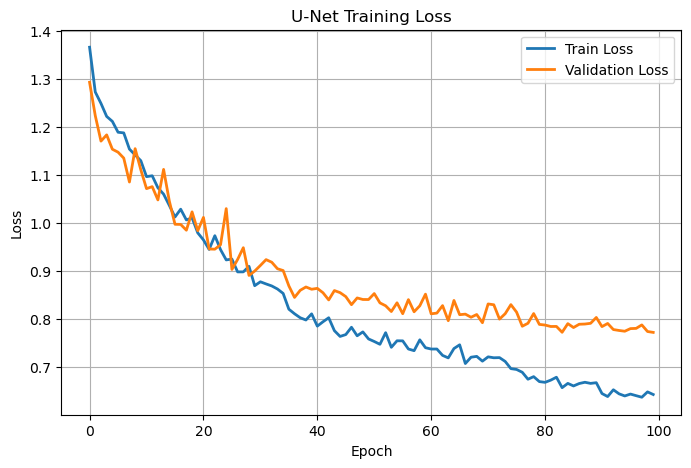

In [96]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("U-Net Training Loss")

plt.legend()

plt.grid(True)

plt.show()

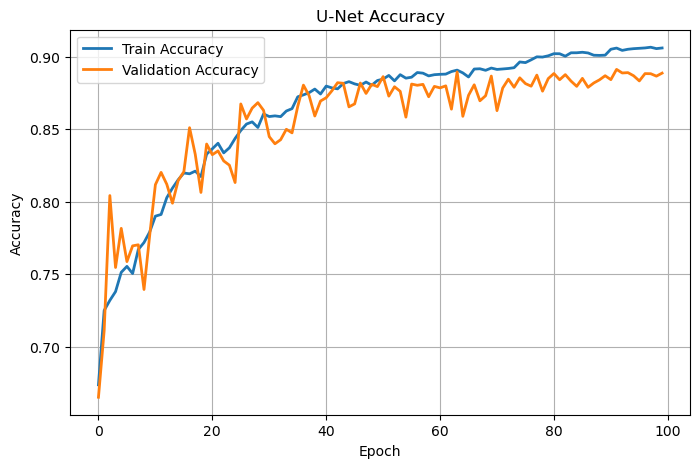

In [98]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    val_accs,
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("U-Net Accuracy")

plt.legend()

plt.grid(True)

plt.show()

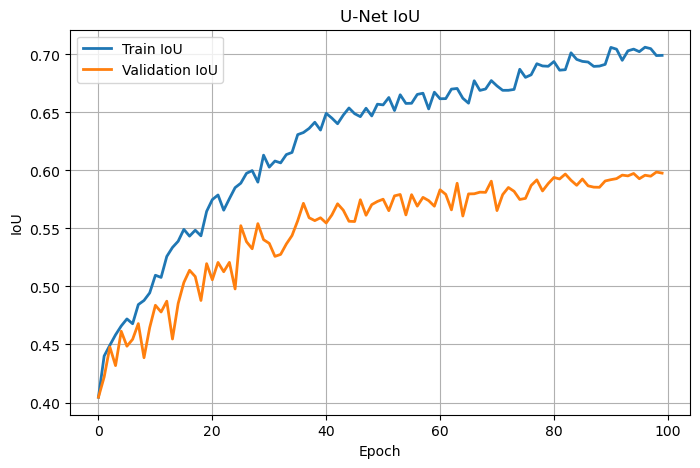

In [100]:
plt.figure(figsize=(8,5))

plt.plot(
    train_ious,
    label="Train IoU",
    linewidth=2
)

plt.plot(
    val_ious,
    label="Validation IoU",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title("U-Net IoU")

plt.legend()

plt.grid(True)

plt.show()

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

In [65]:
model = UNet().to(DEVICE)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [66]:
def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            outputs = model(images)

            preds = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            all_preds.extend(
                preds.cpu().numpy().flatten()
            )

            all_targets.extend(
                masks.numpy().flatten()
            )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    iou = jaccard_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    dice = (
        2 * precision * recall
    ) / (
        precision + recall + 1e-8
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Dice Score": dice,
        "IoU": iou
    }

In [67]:
results = evaluate_model(
    model,
    test_loader,
    DEVICE
)

for metric, value in results.items():

    print(
        f"{metric}: {value:.4f}"
    )

Accuracy: 0.9076
Precision: 0.7906
Recall: 0.8614
F1 Score: 0.8245
Dice Score: 0.8245
IoU: 0.7014


In [74]:
import pandas as pd
metrics_df = pd.DataFrame(
    {
        "Metric": results.keys(),
        "Value": results.values()
    }
)

metrics_df

,Metric,Value
0,Accuracy,0.907586
1,Precision,0.790612
2,Recall,0.861449
3,F1 Score,0.824512
4,Dice Score,0.824512
5,IoU,0.701421


In [79]:
def visualize_predictions(
    model,
    dataset,
    device,
    num_samples=5
):

    model.eval()

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(12, 4*num_samples)
    )

    with torch.no_grad():

        for i in range(num_samples):

            image, mask = dataset[i]

            prediction = model(
                image.unsqueeze(0).to(device)
            )

            prediction = (
                torch.sigmoid(prediction)
                > 0.5
            ).float()

            rgb = image.permute(
                1,
                2,
                0
            ).numpy()

            axes[i,0].imshow(rgb)
            axes[i,0].set_title("RGB Image")
            axes[i,0].axis("off")

            axes[i,1].imshow(
                mask.squeeze(),
                cmap="Blues"
            )
            axes[i,1].set_title("Ground Truth")
            axes[i,1].axis("off")

            axes[i,2].imshow(
                prediction.squeeze().cpu(),
                cmap="Blues"
            )
            axes[i,2].set_title("Prediction")
            axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

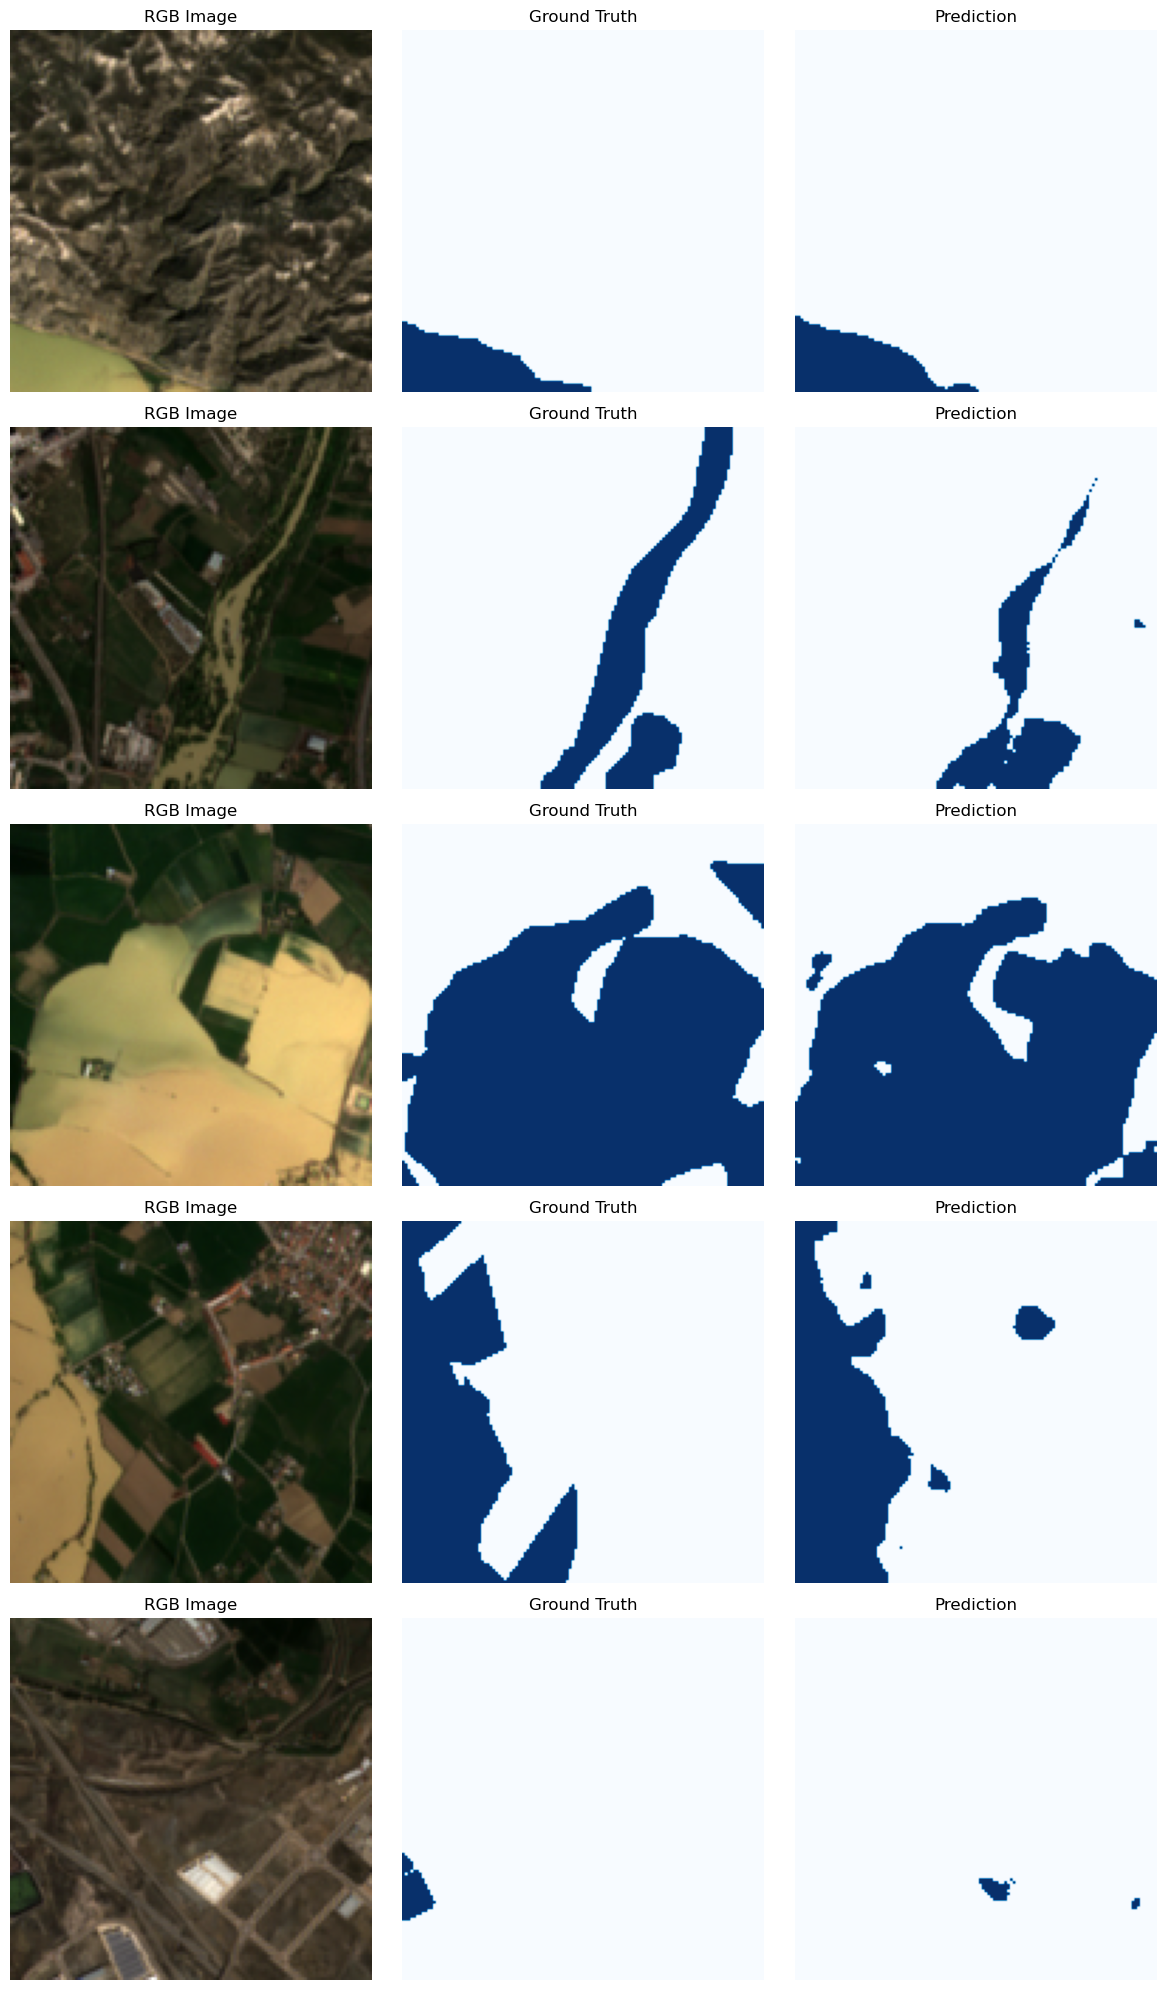

In [104]:
visualize_predictions(
    model,
    test_dataset,
    DEVICE,
    num_samples=5
)

## Notebook Summary – Baseline U-Net Flood Segmentation

This notebook implements and evaluates a baseline **U-Net** model for binary flood segmentation using the preprocessed STRUM Sentinel-2 dataset. The objective is to establish a benchmark performance before introducing more advanced architectures such as the Hybrid SAM-U-Net model.

### Dataset Used

The model was trained using the preprocessed STRUM dataset generated in the previous notebook.

| Property          | Value                      |
| ----------------- | -------------------------- |
| Training Images   | 2,140                      |
| Validation Images | 267                        |
| Test Images       | 268                        |
| Image Shape       | (3, 128, 128)              |
| Mask Shape        | (128, 128)                 |
| Classes           | Binary (Flood / Non-Flood) |
| Image Range       | 0 – 1                      |

### Data Quality Verification

| Check                 | Result |
| --------------------- | ------ |
| Images Containing NaN | 0      |
| Images Containing Inf | 0      |
| Masks Containing NaN  | 0      |
| Mask Classes          | {0, 1} |

### Class Imbalance Analysis

The dataset exhibits class imbalance, with background pixels significantly outnumbering flood pixels.

| Class      | Pixel Count |
| ---------- | ----------: |
| Background |  25,243,294 |
| Flood      |   9,818,466 |

| Metric                |  Value |
| --------------------- | -----: |
| Positive Class Weight | 2.5710 |

This class weight was incorporated into the loss function to reduce bias toward the majority class.

### Model Architecture

The baseline model uses a standard U-Net architecture consisting of:

* Encoder-decoder structure with skip connections
* Double convolution blocks
* Batch normalization
* Max pooling for downsampling
* Transposed convolutions for upsampling
* Sigmoid activation for binary segmentation

| Model Property       |      Value |
| -------------------- | ---------: |
| Input Channels       |          3 |
| Output Channels      |          1 |
| Trainable Parameters | 31,037,633 |

### Training Configuration

| Hyperparameter | Value                          |
| -------------- | ------------------------------ |
| Optimizer      | Adam                           |
| Learning Rate  | 1e-4                           |
| Scheduler      | ReduceLROnPlateau              |
| Epochs         | 100                            |
| Batch Size     | 8                              |
| Loss Function  | Weighted BCE + Dice Loss       |
| Device         | NVIDIA GeForce RTX 2050 (CUDA) |

### Validation Performance

| Metric         | Best Value |
| -------------- | ---------: |
| Validation IoU |     0.5681 |

The best-performing model checkpoint was saved based on validation IoU.

### Test Set Performance

| Metric     |  Score |
| ---------- | -----: |
| Accuracy   | 0.8984 |
| Precision  | 0.7823 |
| Recall     | 0.8269 |
| F1 Score   | 0.8040 |
| Dice Score | 0.8040 |
| IoU        | 0.6722 |

### Visual Evaluation

Qualitative predictions were generated on test samples by comparing:

1. Input RGB image
2. Ground-truth flood mask
3. Predicted flood mask

These visualizations provide additional confirmation that the model successfully identifies flooded regions while preserving spatial structure.

## Conclusion

A baseline U-Net model was successfully trained for binary flood segmentation on the STRUM dataset. To address class imbalance, a weighted BCE-Dice loss function was employed using a positive class weight of 2.571. The model achieved a test IoU of 0.6722 and a Dice score of 0.8040, demonstrating strong segmentation performance and providing a reliable benchmark for comparison with more advanced architectures in subsequent experiments.
